In [2]:
import warnings
warnings.filterwarnings("ignore")

import subprocess, sys
import itertools
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import norm, gaussian_kde
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import yfinance as yf

# Installation des dépendances
for pkg in ["yfinance", "scikit-learn", "scipy", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Imports OK")




[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


✅ Imports OK



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
# Partie 1 : Exploration initiale
PERIOD  = '5y'
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']

# Partie 2 : Markowitz
ASSETS = {
    "GS":        "Goldman Sachs",
    "BNP.PA":    "BNP Paribas",
    "GOOGL":     "Alphabet",
    "NOVO-B.CO": "Novo Nordisk",
    "URW.AS":    "Unibail-Rodamco",
    "AMT":       "American Tower",
    "APO":       "Apollo Global",
    "ARES":      "Ares Management",
    "IHYG.L":    "iShares HY Bond",
    "VECP.L":    "Vanguard Corp Bond",
    "CSH2.PA":   "Amundi Overnight",
}

START_DATE     = "2019-01-01"
END_DATE       = datetime.today().strftime("%Y-%m-%d")
RISK_FREE_RATE = 0.03
TRADING_DAYS   = 252
COMBO_MIN_K    = 4
COMBO_MAX_K    = 6
TOP_N_COMBOS   = 20
MAX_WEIGHT     = 0.30
SHRINK_ALPHA   = 0.5
TRAIN_YEARS    = 3
TEST_YEARS     = 1

SCREEN = {
    "sharpe_min":    0.2,
    "mdd_max":      -0.60,
    "momentum_min": -0.15,
}

PALETTE = {
    "frontier": "#378ADD", "combos": "#B4B2A9", "sharpe": "#EF9F27",
    "minvol": "#1D9E75", "rf": "#D85A30", "real": "#534AB7",
    "grid": "#E8E6E0", "text": "#3d3d3a", "bg": "#FAFAF8",
}

COULEURS_BENCH = {
    "CAC 40":          "#1f77b4",
    "S&P 500":         "#2ca02c",
    "MSCI World":      "#ff7f0e",
    "Notre stratégie": "#d62728",
}



In [4]:
# Téléchargement des données (5 actions, 5 ans)
df = yf.download(TICKERS, period=PERIOD, group_by='ticker')

# Restructuration en dictionnaire par ticker
data = {ticker: df[ticker] for ticker in TICKERS}

# Aperçu
print(df.info())
print(df.head())

[*********************100%***********************]  5 of 5 completed

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-06-17 to 2026-06-16
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (GOOGL, Open)    1255 non-null   float64
 1   (GOOGL, High)    1255 non-null   float64
 2   (GOOGL, Low)     1255 non-null   float64
 3   (GOOGL, Close)   1255 non-null   float64
 4   (GOOGL, Volume)  1255 non-null   int64  
 5   (MSFT, Open)     1255 non-null   float64
 6   (MSFT, High)     1255 non-null   float64
 7   (MSFT, Low)      1255 non-null   float64
 8   (MSFT, Close)    1255 non-null   float64
 9   (MSFT, Volume)   1255 non-null   int64  
 10  (AAPL, Open)     1255 non-null   float64
 11  (AAPL, High)     1255 non-null   float64
 12  (AAPL, Low)      1255 non-null   float64
 13  (AAPL, Close)    1255 non-null   float64
 14  (AAPL, Volume)   1255 non-null   int64  
 15  (JPM, Open)      1255 non-null   float64
 16  (JPM, High)      1255 non-null   float64
 17  (JPM, L

In [5]:
# Vérification NaN
for ticker in TICKERS:
    nan_count = data[ticker].isna().sum()
    if nan_count.any():
        print(f"\n{ticker}:")
        print(nan_count[nan_count > 0])
    else:
        print(f"{ticker}: aucun NaN")

# Statistiques descriptives
print(df.describe())

# Outliers (méthode IQR)
for ticker in TICKERS:
    print(f"\n{ticker}:")
    for col in data[ticker].select_dtypes(include='number').columns:
        Q1, Q3 = data[ticker][col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        n = ((data[ticker][col] < Q1 - 1.5*IQR) | (data[ticker][col] > Q3 + 1.5*IQR)).sum()
        print(f"  {col}: {n} outliers")

AAPL: aucun NaN
MSFT: aucun NaN
GOOGL: aucun NaN
AMZN: aucun NaN
JPM: aucun NaN
Ticker        GOOGL                                                       \
Price          Open         High          Low        Close        Volume   
count   1255.000000  1255.000000  1255.000000  1255.000000  1.255000e+03   
mean     166.233883   168.218955   164.352127   166.363561  3.219856e+07   
std       69.855054    70.726241    68.995896    69.979530  1.360869e+07   
min       84.649387    85.759546    82.607496    82.696709  9.701400e+06   
25%      122.156801   124.119409   121.180460   122.568161  2.351190e+07   
50%      142.702619   143.725553   141.149889   142.428055  2.894010e+07   
75%      177.396394   179.436212   175.149976   177.167450  3.658815e+07   
max      399.681282   408.366081   396.123378   402.379669  1.274901e+08   

Ticker         MSFT                                                       ...  \
Price          Open         High          Low        Close        Volume  ... 

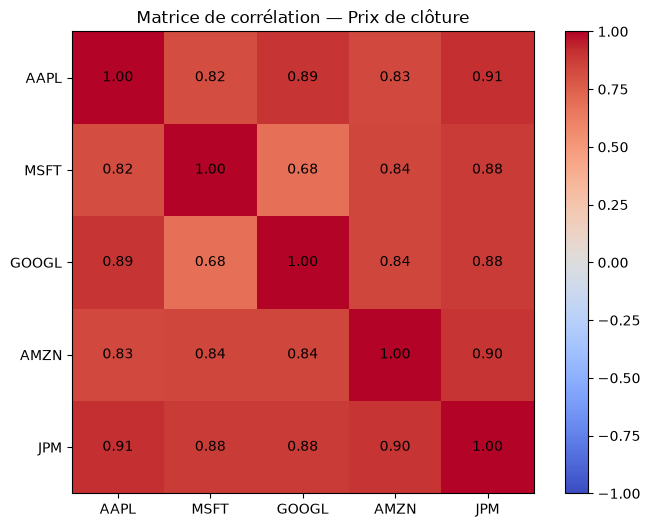

In [6]:
closes = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in TICKERS})
corr = closes.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(TICKERS)), TICKERS)
plt.yticks(range(len(TICKERS)), TICKERS)
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.title('Matrice de corrélation — Prix de clôture')
plt.show()

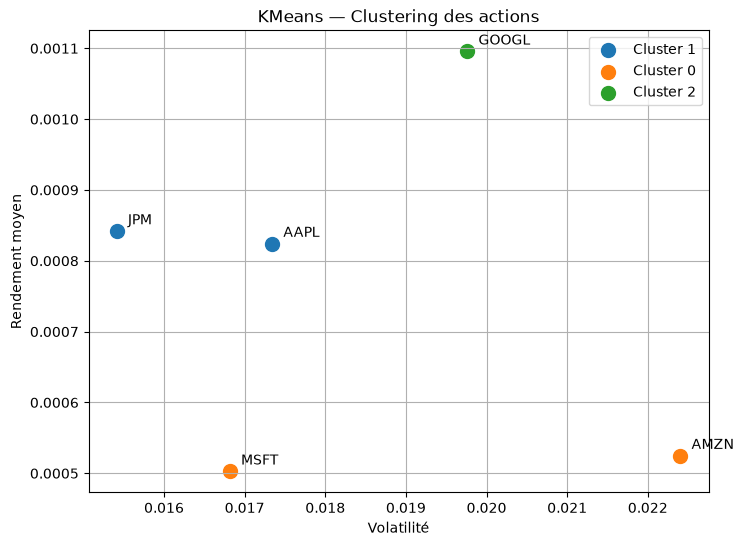

       rendement_moyen  volatilite  cluster
AAPL          0.000824    0.017342        1
MSFT          0.000503    0.016817        0
GOOGL         0.001095    0.019762        2
AMZN          0.000525    0.022405        0
JPM           0.000842    0.015414        1


In [7]:
closes = pd.DataFrame({ticker: data[ticker]['Close'] for ticker in TICKERS})
returns = closes.pct_change().dropna()

features = pd.DataFrame({
    'rendement_moyen': returns.mean(),
    'volatilite': returns.std()
})

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
features['cluster'] = kmeans.fit_predict(features_scaled)

plt.figure(figsize=(8, 6))
for cluster in features['cluster'].unique():
    subset = features[features['cluster'] == cluster]
    plt.scatter(subset['volatilite'], subset['rendement_moyen'], label=f'Cluster {cluster}', s=100)
    for ticker in subset.index:
        plt.annotate(ticker, (subset.loc[ticker, 'volatilite'], subset.loc[ticker, 'rendement_moyen']),
                     textcoords='offset points', xytext=(8, 5))
plt.xlabel('Volatilité')
plt.ylabel('Rendement moyen')
plt.title('KMeans — Clustering des actions')
plt.legend()
plt.grid(True)
plt.show()

print(features)

In [8]:
def selectionner_par_cluster(features, returns, critere="sharpe"):
    selection = []
    for cluster in sorted(features["cluster"].unique()):
        membres = features[features["cluster"] == cluster].index
        if critere == "sharpe":
            sharpe = returns[membres].mean() / returns[membres].std()
            choisi = sharpe.idxmax()
        elif critere == "rendement":
            choisi = returns[membres].mean().idxmax()
        elif critere == "min_vol":
            choisi = returns[membres].std().idxmin()
        else:
            choisi = membres[0]
        selection.append(choisi)
        print(f"Cluster {cluster} : {list(membres)}  ->  choisi : {choisi}")
    return selection

def calculer_variance_portefeuille(returns, tickers, poids=None):
    sub_returns = returns[tickers]
    Sigma = sub_returns.cov()
    n = len(tickers)
    w = np.array([1.0 / n] * n) if poids is None else np.array(poids) / np.sum(poids)
    variance_p = w.T @ Sigma.values @ w
    volatilite_p = np.sqrt(variance_p)
    return variance_p, volatilite_p, Sigma, w

print("=== Sélection d'un actif par cluster ===")
actifs = selectionner_par_cluster(features, returns, critere="sharpe")
print(f"\nPortefeuille diversifié : {actifs}\n")

var_p, vol_p, Sigma, w = calculer_variance_portefeuille(returns, actifs)
print(f"Volatilité annualisée : {vol_p * np.sqrt(252) * 100:.2f}%")

=== Sélection d'un actif par cluster ===
Cluster 0 : ['MSFT', 'AMZN']  ->  choisi : MSFT
Cluster 1 : ['AAPL', 'JPM']  ->  choisi : JPM
Cluster 2 : ['GOOGL']  ->  choisi : GOOGL

Portefeuille diversifié : ['MSFT', 'JPM', 'GOOGL']

Volatilité annualisée : 21.54%


In [9]:
def rendements_portefeuille(returns, tickers, poids=None):
    n = len(tickers)
    w = np.array([1.0 / n] * n) if poids is None else np.array(poids) / np.sum(poids)
    return returns[tickers] @ w

def var_parametrique(r, niveau=0.95):
    return r.mean() - r.std() * norm.ppf(niveau)

def var_historique(r, niveau=0.95):
    return np.quantile(r, 1 - niveau)

def var_monte_carlo(r, niveau=0.95, n_sim=100_000, seed=42):
    rng = np.random.default_rng(seed)
    simulations = rng.normal(r.mean(), r.std(), n_sim)
    return np.quantile(simulations, 1 - niveau)

def cvar_historique(r, niveau=0.95):
    seuil = np.quantile(r, 1 - niveau)
    return r[r <= seuil].mean()

r = rendements_portefeuille(returns, actifs)
niveau = 0.95

var_p  = var_parametrique(r, niveau)
var_h  = var_historique(r, niveau)
var_mc = var_monte_carlo(r, niveau)
cvar   = cvar_historique(r, niveau)

print(f"=== VaR à {int(niveau*100)}% ===\n")
print(f"VaR paramétrique (gaussienne) : {var_p:.4%}")
print(f"VaR historique  (empirique)   : {var_h:.4%}")
print(f"VaR Monte Carlo (simulée)     : {var_mc:.4%}")
print(f"CVaR / Expected Shortfall     : {cvar:.4%}")

# Analyse critique
ecart = (var_h - var_p) / abs(var_p) * 100
print(f"\nÉcart historique vs gaussienne : {ecart:+.1f}%")
k = r.kurtosis()
print(f"Kurtosis excédentaire : {k:.2f}")
if k > 0:
    print("=> Queues épaisses : VaR gaussienne trop optimiste")

=== VaR à 95% ===

VaR paramétrique (gaussienne) : -2.1506%
VaR historique  (empirique)   : -2.1260%
VaR Monte Carlo (simulée)     : -2.1689%
CVaR / Expected Shortfall     : -2.9896%

Écart historique vs gaussienne : +1.1%
Kurtosis excédentaire : 3.15
=> Queues épaisses : VaR gaussienne trop optimiste


[*********************100%***********************]  1 of 1 completed

VaR estimée               : -1.6355%
Dépassements observés     : 13
Dépassements attendus     : 12.6
Taux observé              : 5.16%  (théorique : 5.00%)

Tracking Error annualisée : 10.8900%


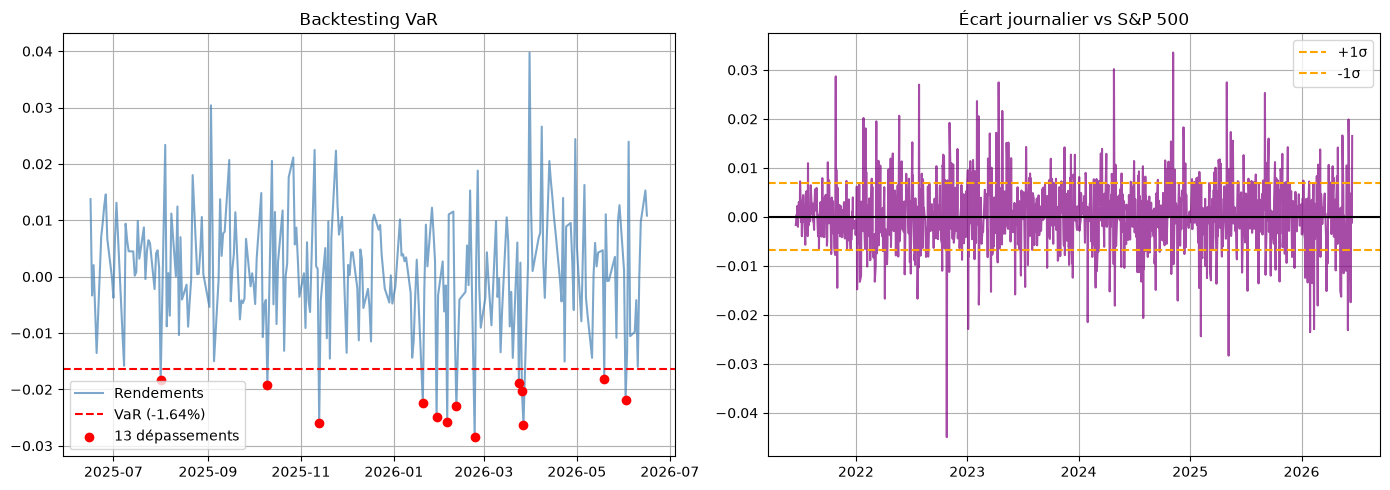

In [10]:
sp = yf.download("^GSPC", period=PERIOD)["Close"]
sp500_returns = sp.pct_change().dropna().squeeze()

def compter_depassements(r, niveau=0.95, fenetre=252):
    r_recent = r.iloc[-fenetre:]
    mu, sigma = r_recent.mean(), r_recent.std()
    VaR = mu - sigma * norm.ppf(niveau)
    depassements = r_recent[r_recent < VaR]
    n_dep = len(depassements)
    attendu = (1 - niveau) * len(r_recent)
    print(f"VaR estimée               : {VaR:.4%}")
    print(f"Dépassements observés     : {n_dep}")
    print(f"Dépassements attendus     : {attendu:.1f}")
    print(f"Taux observé              : {n_dep/len(r_recent):.2%}  (théorique : {1-niveau:.2%})")
    return n_dep, attendu, VaR, depassements

def tracking_error(r_portefeuille, r_benchmark, annualiser=True):
    df = pd.concat([r_portefeuille, r_benchmark], axis=1).dropna()
    df.columns = ["portefeuille", "benchmark"]
    difference = df["portefeuille"] - df["benchmark"]
    te = difference.std() * (np.sqrt(252) if annualiser else 1)
    return te, difference

r_portefeuille = rendements_portefeuille(returns, actifs)
n_dep, attendu, VaR, depassements = compter_depassements(r_portefeuille)
te, diff = tracking_error(r_portefeuille, sp500_returns)
print(f"\nTracking Error annualisée : {te:.4%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
r_recent = r_portefeuille.iloc[-252:]
axes[0].plot(r_recent.index, r_recent, color='steelblue', alpha=0.7, label='Rendements')
axes[0].axhline(VaR, color='red', linestyle='--', label=f'VaR ({VaR:.2%})')
axes[0].scatter(depassements.index, depassements, color='red', zorder=5, label=f'{n_dep} dépassements')
axes[0].set_title('Backtesting VaR')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(diff.index, diff, color='purple', alpha=0.7)
axes[1].axhline(0, color='black')
axes[1].axhline(diff.std(), color='orange', linestyle='--', label='+1σ')
axes[1].axhline(-diff.std(), color='orange', linestyle='--', label='-1σ')
axes[1].set_title('Écart journalier vs S&P 500')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [11]:
def stress_test_choc(actifs, poids=None, choc=-0.20, capital=100_000):
    n = len(actifs)
    w = np.array([1.0 / n] * n) if poids is None else np.array(poids) / np.sum(poids)
    impact = np.sum(w * choc)
    perte = capital * impact
    print(f"Choc appliqué : {choc:.0%}")
    print(f"Impact portefeuille : {impact:.2%}")
    print(f"Perte sur {capital:,.0f} EUR : {perte:,.0f} EUR")
    return impact

def correlation_normale_vs_crise(returns, actifs, seuil_crise=0.05):
    sub = returns[actifs]
    marche = sub.mean(axis=1)
    seuil = marche.quantile(seuil_crise)
    def correlation_moyenne(df):
        c = df.corr().values
        n = c.shape[0]
        return (c.sum() - n) / (n * n - n)
    corr_normale = correlation_moyenne(sub[marche > seuil])
    corr_crise   = correlation_moyenne(sub[marche <= seuil])
    print(f"Corrélation en temps normal : {corr_normale:.3f}")
    print(f"Corrélation en crise        : {corr_crise:.3f}")
    print(f"Variation                   : {corr_crise - corr_normale:+.3f}")
    return corr_normale, corr_crise

stress_test_choc(actifs, choc=-0.20, capital=100_000)
corr_normale, corr_crise = correlation_normale_vs_crise(returns, actifs)

Choc appliqué : -20%
Impact portefeuille : -20.00%
Perte sur 100,000 EUR : -20,000 EUR
Corrélation en temps normal : 0.331
Corrélation en crise        : -0.245
Variation                   : -0.577


In [12]:
def download_prices(tickers, start, end):
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=True)
    prices = raw["Close"][tickers].dropna(how="all")
    print(f"{len(prices)} jours | {prices.shape[1]} actifs")
    return prices

tickers = list(ASSETS.keys())
prices = download_prices(tickers, START_DATE, END_DATE)
available = [t for t in tickers if t in prices.columns and prices[t].notna().sum() > 200]
print(f"Actifs disponibles : {available}")

[**********************82%**************         ]  9 of 11 completed$URW.AS: possibly delisted; no timezone found
[*********************100%***********************]  11 of 11 completed

1 Failed download:
['URW.AS']: possibly delisted; no timezone found


1927 jours | 11 actifs
Actifs disponibles : ['GS', 'BNP.PA', 'GOOGL', 'NOVO-B.CO', 'AMT', 'APO', 'ARES', 'IHYG.L', 'VECP.L', 'CSH2.PA']


In [13]:
def max_drawdown(s):
    roll_max = s.cummax()
    return float(((s - roll_max) / roll_max).min())

def momentum(s, months=12):
    days = int(months * 21)
    return float(s.iloc[-1] / s.iloc[-days] - 1) if len(s) >= days else np.nan

def compute_screening(prices):
    log_ret = np.log(prices / prices.shift(1)).dropna()
    rows = []
    for t in prices.columns:
        s = prices[t].dropna()
        r = log_ret[t].dropna()
        ann_r = r.mean() * TRADING_DAYS
        ann_v = r.std() * np.sqrt(TRADING_DAYS)
        sharpe = (ann_r - RISK_FREE_RATE) / ann_v if ann_v > 0 else np.nan
        mdd = max_drawdown(s)
        rows.append({
            "Ticker": t, "Nom": ASSETS.get(t, t),
            "Rend. ann.": ann_r, "Vol. ann.": ann_v, "Sharpe": sharpe,
            "MDD": mdd, "Calmar": ann_r / abs(mdd) if mdd != 0 else np.nan,
            "Mom 12M": momentum(s, 12), "Mom  3M": momentum(s, 3),
        })
    return pd.DataFrame(rows).set_index("Ticker"), log_ret

def apply_filters(df):
    mask = (
        (df["Sharpe"]  >= SCREEN["sharpe_min"]) &
        (df["MDD"]     >= SCREEN["mdd_max"]) &
        (df["Mom 12M"] >= SCREEN["momentum_min"])
    )
    passed = df[mask].index.tolist()
    removed = df[~mask].index.tolist()
    print(f"Retenus ({len(passed)}) : {', '.join(passed)}")
    print(f"Exclus  ({len(removed)}) : {', '.join(removed) if removed else '—'}")
    return passed, removed

screening_df, log_ret = compute_screening(prices[available])
selected, removed = apply_filters(screening_df)

if len(selected) < COMBO_MIN_K:
    selected = available

Retenus (5) : GS, BNP.PA, GOOGL, IHYG.L, VECP.L
Exclus  (5) : NOVO-B.CO, AMT, APO, ARES, CSH2.PA


In [14]:
def ledoit_wolf_shrinkage(log_ret_df):
    X = log_ret_df.values
    n, p = X.shape
    S = np.cov(X.T) * TRADING_DAYS
    target = np.diag(np.diag(S))
    mu_bar = np.trace(S) / p
    delta = np.linalg.norm(S - mu_bar * np.eye(p), "fro")**2
    gamma = np.linalg.norm(S - target, "fro")**2
    alpha = max(0, min(1, (delta - gamma) / (delta + 1e-12)))
    return (1 - alpha) * S + alpha * target, alpha

def shrink_mu(mu_raw, alpha=SHRINK_ALPHA):
    return (1 - alpha) * mu_raw + alpha * mu_raw.mean()

def portfolio_stats(w, mu, cov):
    w = np.array(w)
    ret = float(w @ mu)
    vol = float(np.sqrt(w @ cov @ w))
    sharpe = (ret - RISK_FREE_RATE) / vol if vol > 0 else 0.0
    return ret, vol, sharpe

def optimise_max_sharpe(mu, cov, max_w=MAX_WEIGHT):
    n = len(mu)
    def neg_sharpe(w): return -portfolio_stats(w, mu, cov)[2]
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0.0, max_w)] * n
    best_res = None
    for _ in range(5):
        w0 = np.random.dirichlet(np.ones(n))
        res = minimize(neg_sharpe, w0, method="SLSQP", bounds=bounds,
                       constraints=constraints, options={"maxiter": 1000})
        if res.success and (best_res is None or res.fun < best_res.fun):
            best_res = res
    return best_res.x if best_res else np.ones(n) / n

def optimise_min_vol(mu, cov, max_w=MAX_WEIGHT):
    n = len(mu)
    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
    bounds = [(0.0, max_w)] * n
    res = minimize(lambda w: float(np.sqrt(np.array(w) @ cov @ np.array(w))),
                   np.ones(n)/n, method="SLSQP", bounds=bounds, constraints=constraints)
    return res.x if res.success else np.ones(n)/n

print("✅ Fonctions d'optimisation chargées")

✅ Fonctions d'optimisation chargées


In [15]:
def walk_forward_backtest(prices, selected):
    prices_sel = prices[selected].dropna()
    log_ret = np.log(prices_sel / prices_sel.shift(1)).dropna()
    train_days = int(TRAIN_YEARS * TRADING_DAYS)
    test_days  = int(TEST_YEARS * TRADING_DAYS)
    results, start, window = [], 0, 0
    while start + train_days + test_days <= len(log_ret):
        train = log_ret.iloc[start : start + train_days]
        test  = log_ret.iloc[start + train_days : start + train_days + test_days]
        mu_sh  = shrink_mu(train.mean() * TRADING_DAYS)
        cov_sh, _ = ledoit_wolf_shrinkage(train)
        mu_arr = mu_sh[selected].values
        w = optimise_max_sharpe(mu_arr, cov_sh)
        test_ret = test[selected].values @ w
        r_re = float(test_ret.mean() * TRADING_DAYS)
        v_re = float(test_ret.std() * np.sqrt(TRADING_DAYS))
        s_re = (r_re - RISK_FREE_RATE) / v_re if v_re > 0 else np.nan
        r_th, v_th, s_th = portfolio_stats(w, mu_arr, cov_sh)
        results.append({"fenêtre": window+1, "sharpe_théo": s_th, "sharpe_réel": s_re,
                         "écart_sharpe": s_re - s_th})
        window += 1; start += test_days
    df_wf = pd.DataFrame(results)
    print(df_wf.to_string(index=False))
    return df_wf

def run_combinations(selected, prices):
    log_ret = np.log(prices[selected] / prices[selected].shift(1)).dropna()
    mu_sh = shrink_mu(log_ret.mean() * TRADING_DAYS)
    cov_sh, _ = ledoit_wolf_shrinkage(log_ret)
    results = []
    for k in range(COMBO_MIN_K, COMBO_MAX_K + 1):
        for combo in itertools.combinations(selected, k):
            combo = list(combo)
            idx = [selected.index(t) for t in combo]
            mu_c  = mu_sh.values[idx]
            cov_c = cov_sh[np.ix_(idx, idx)]
            w = optimise_max_sharpe(mu_c, cov_c)
            r, v, s = portfolio_stats(w, mu_c, cov_c)
            results.append({"combo": tuple(combo), "k": k, "sharpe": s,
                             "ret": r, "vol": v, "weights": dict(zip(combo, w.round(4)))})
    df_combos = pd.DataFrame(results).sort_values("sharpe", ascending=False)
    best = df_combos.iloc[0]
    print(f"\n=== Meilleure combo ===")
    print(f"Actifs : {' | '.join(best['combo'])}")
    print(f"Sharpe : {best['sharpe']:.3f} | Rend : {best['ret']:.2%} | Vol : {best['vol']:.2%}")
    return df_combos, log_ret, mu_sh, cov_sh

df_wf = walk_forward_backtest(prices, selected)
df_combos, log_ret_sel, mu_sh, cov_sh = run_combinations(selected, prices)
best = df_combos.iloc[0]

 fenêtre  sharpe_théo  sharpe_réel  écart_sharpe
       1     0.893300    -0.663043     -1.556343
       2     0.246848     0.581967      0.335119
       3     0.399094     1.724033      1.324939
       4     0.640472     1.308569      0.668096

=== Meilleure combo ===
Actifs : GS | BNP.PA | GOOGL | IHYG.L | VECP.L
Sharpe : 1.088 | Rend : 14.25% | Vol : 10.34%


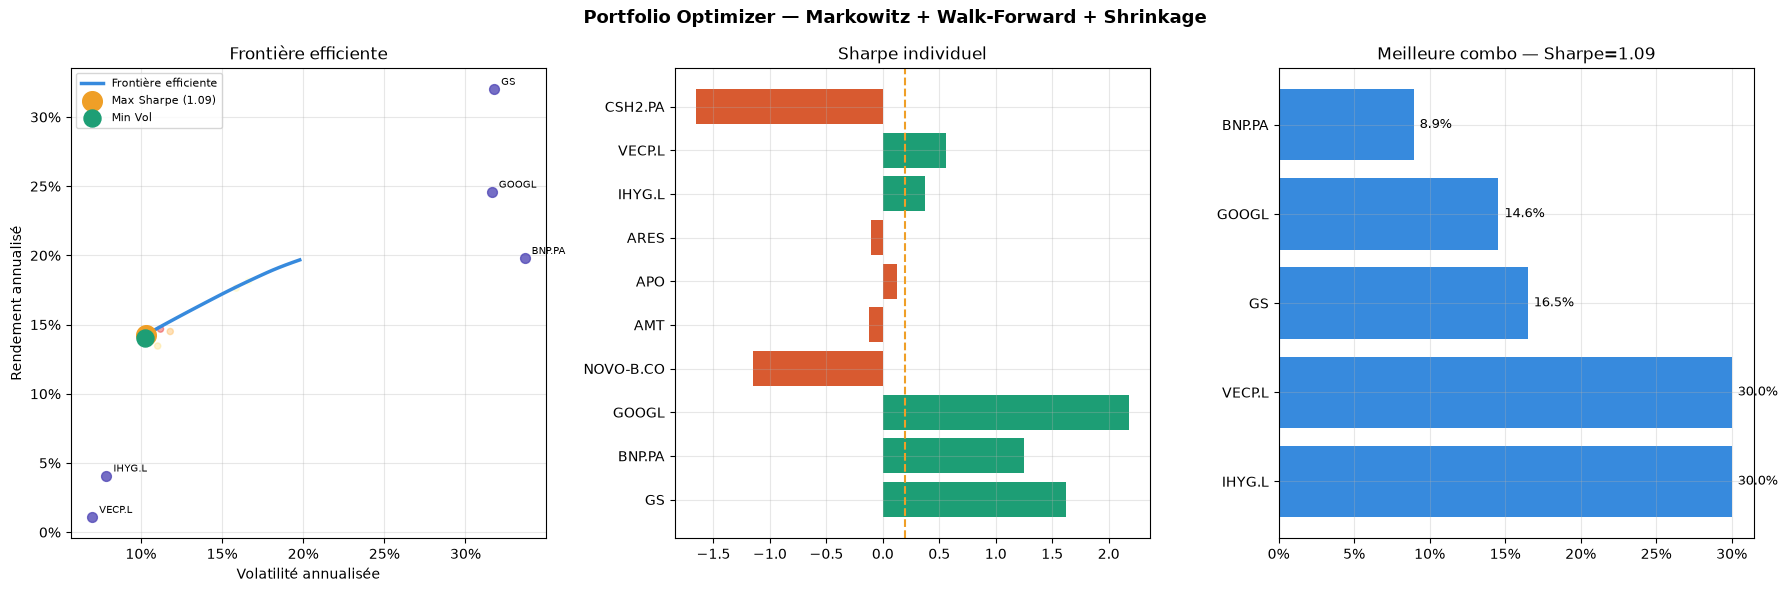

In [16]:
def frontier_points(mu, cov, n_pts=50, max_w=MAX_WEIGHT):
    w_mv = optimise_min_vol(mu, cov, max_w)
    r_min = float(w_mv @ mu)
    r_max = float(np.max(mu)) * 0.95
    pts = []
    n = len(mu)
    for tgt in np.linspace(r_min, r_max, n_pts):
        constraints = [
            {"type": "eq", "fun": lambda w: np.sum(w) - 1},
            {"type": "eq", "fun": lambda w, t=tgt: float(np.array(w) @ mu) - t},
        ]
        res = minimize(lambda w: float(np.sqrt(np.array(w) @ cov @ np.array(w))),
                       np.ones(n)/n, method="SLSQP", bounds=[(0, max_w)]*n,
                       constraints=constraints)
        if res.success:
            r, v, s = portfolio_stats(res.x, mu, cov)
            pts.append({"ret": r, "vol": v, "sharpe": s})
    return pd.DataFrame(pts)

mu_arr  = mu_sh[selected].values
cov_arr = cov_sh
front   = frontier_points(mu_arr, cov_arr)
w_ms    = optimise_max_sharpe(mu_arr, cov_arr)
r_ms, v_ms, s_ms = portfolio_stats(w_ms, mu_arr, cov_arr)
w_mv    = optimise_min_vol(mu_arr, cov_arr)
r_mv, v_mv, _ = portfolio_stats(w_mv, mu_arr, cov_arr)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Frontière efficiente
ax = axes[0]
ax.scatter(df_combos["vol"], df_combos["ret"], c=df_combos["sharpe"],
           cmap="YlOrRd", s=20, alpha=0.4)
if not front.empty:
    ax.plot(front["vol"], front["ret"], color=PALETTE["frontier"], lw=2.5, label="Frontière efficiente")
ax.scatter(v_ms, r_ms, s=200, color=PALETTE["sharpe"], zorder=5, label=f"Max Sharpe ({s_ms:.2f})")
ax.scatter(v_mv, r_mv, s=150, color=PALETTE["minvol"], zorder=5, label="Min Vol")
for t in selected:
    v = log_ret_sel[t].std() * np.sqrt(TRADING_DAYS)
    r = log_ret_sel[t].mean() * TRADING_DAYS
    ax.scatter(v, r, s=50, color=PALETTE["real"], zorder=4, alpha=0.8)
    ax.annotate(t, (v, r), fontsize=7, xytext=(5, 3), textcoords="offset points")
ax.set_title("Frontière efficiente")
ax.set_xlabel("Volatilité annualisée")
ax.set_ylabel("Rendement annualisé")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Sharpe individuel
ax = axes[1]
colors = ["#1D9E75" if s >= SCREEN["sharpe_min"] else "#D85A30" for s in screening_df["Sharpe"]]
ax.barh(screening_df.index, screening_df["Sharpe"], color=colors)
ax.axvline(SCREEN["sharpe_min"], color=PALETTE["sharpe"], lw=1.5, linestyle="--")
ax.set_title("Sharpe individuel")
ax.grid(True, alpha=0.3)

# Poids meilleure combo
ax = axes[2]
w_dict = dict(sorted(best["weights"].items(), key=lambda x: -x[1]))
ax.barh(list(w_dict.keys()), list(w_dict.values()), color=PALETTE["frontier"])
for i, (k, v) in enumerate(w_dict.items()):
    ax.text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title(f"Meilleure combo — Sharpe={best['sharpe']:.2f}")
ax.grid(True, alpha=0.3)

plt.suptitle("Portfolio Optimizer — Markowitz + Walk-Forward + Shrinkage", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
BENCHMARKS = {"CAC 40": "^FCHI", "S&P 500": "^GSPC", "MSCI World": "URTH"}
prix_bench = yf.download(list(BENCHMARKS.values()), start=START_DATE, end=END_DATE, auto_adjust=True)["Close"]
prix_bench.columns = list(BENCHMARKS.keys())
prix_bench = prix_bench.dropna(how="all")
cumul_bench = (1 + prix_bench.pct_change().dropna()).cumprod()

poids_strat   = best["weights"]
tickers_strat = list(poids_strat.keys())
w_strat       = np.array(list(poids_strat.values()))
prix_strat    = prices[tickers_strat].dropna()
rend_strat    = prix_strat.pct_change().dropna() @ w_strat
cumul_strat   = (1 + rend_strat).cumprod()

comparaison = cumul_bench.copy()
comparaison["Notre stratégie"] = cumul_strat
comparaison = comparaison.dropna()
comparaison = comparaison / comparaison.iloc[0]

print(comparaison.tail())

[*********************100%***********************]  3 of 3 completed

              CAC 40   S&P 500  MSCI World  Notre stratégie
Date                                                       
2026-06-10  3.180708  1.997364    3.266011         2.510610
2026-06-11  3.246758  2.006900    3.323228         2.528762
2026-06-12  3.259324  2.043625    3.339929         2.556101
2026-06-15  3.302365  2.051735    3.395133         2.582036
2026-06-16  3.293769  2.067216    3.375834         2.594758


In [18]:
def calculer_rendements(serie_cumul):
    total = serie_cumul.iloc[-1] - 1
    annualise = serie_cumul.iloc[-1] ** (1 / (len(serie_cumul) / 252)) - 1
    return total, annualise

def calculer_drawdown(serie_cumul):
    roll_max = serie_cumul.cummax()
    return (serie_cumul - roll_max) / roll_max

def calculer_risque(serie_cumul, niveau=0.95):
    rend = serie_cumul.pct_change().dropna()
    vol_ann = rend.std() * np.sqrt(252)
    roll_max = serie_cumul.cummax()
    mdd = ((serie_cumul - roll_max) / roll_max).min()
    var_hist = np.quantile(rend, 1 - niveau)
    cvar = rend[rend <= var_hist].mean()
    var_param = rend.mean() - rend.std() * norm.ppf(niveau)
    return {
        "Volatilité annualisée": vol_ann,
        "Max Drawdown": mdd,
        f"VaR {int(niveau*100)}% (historique)": var_hist,
        f"VaR {int(niveau*100)}% (gaussienne)": var_param,
        "CVaR (Expected Shortfall)": cvar,
        "Skewness": rend.skew(),
        "Kurtosis": rend.kurtosis(),
    }

def score_srri(vol_ann):
    for niveau, borne in enumerate([0.005, 0.02, 0.05, 0.10, 0.15, 0.25], start=1):
        if vol_ann < borne:
            return niveau
    return 7



In [19]:
print(f"{'Actif':<20}{'Rdt total':>14}{'CAGR':>12}{'Vol. ann.':>12}{'Sharpe':>10}")
print("-" * 68)
for col in comparaison.columns:
    total, cagr = calculer_rendements(comparaison[col])
    rend_journ = comparaison[col].pct_change().dropna()
    vol_ann = rend_journ.std() * np.sqrt(252)
    sharpe = (cagr - RISK_FREE_RATE) / vol_ann if vol_ann > 0 else np.nan
    print(f"{col:<20}{total:>13.2%}{cagr:>11.2%}{vol_ann:>11.2%}{sharpe:>10.2f}")

capital_initial = 100
valeur_euros = comparaison * capital_initial
print(f"\n{'Actif':<20}{'Valeur finale':>16}")
print("-" * 36)
for col in valeur_euros.columns:
    print(f"{col:<20}{valeur_euros[col].iloc[-1]:>14.2f}€")

Actif                    Rdt total        CAGR   Vol. ann.    Sharpe
--------------------------------------------------------------------
CAC 40                    229.38%     18.59%     18.95%      0.82
S&P 500                   106.72%     10.94%     19.14%      0.42
MSCI World                237.58%     19.01%     19.85%      0.81
Notre stratégie           159.48%     14.61%     12.35%      0.94

Actif                  Valeur finale
------------------------------------
CAC 40                      329.38€
S&P 500                     206.72€
MSCI World                  337.58€
Notre stratégie             259.48€


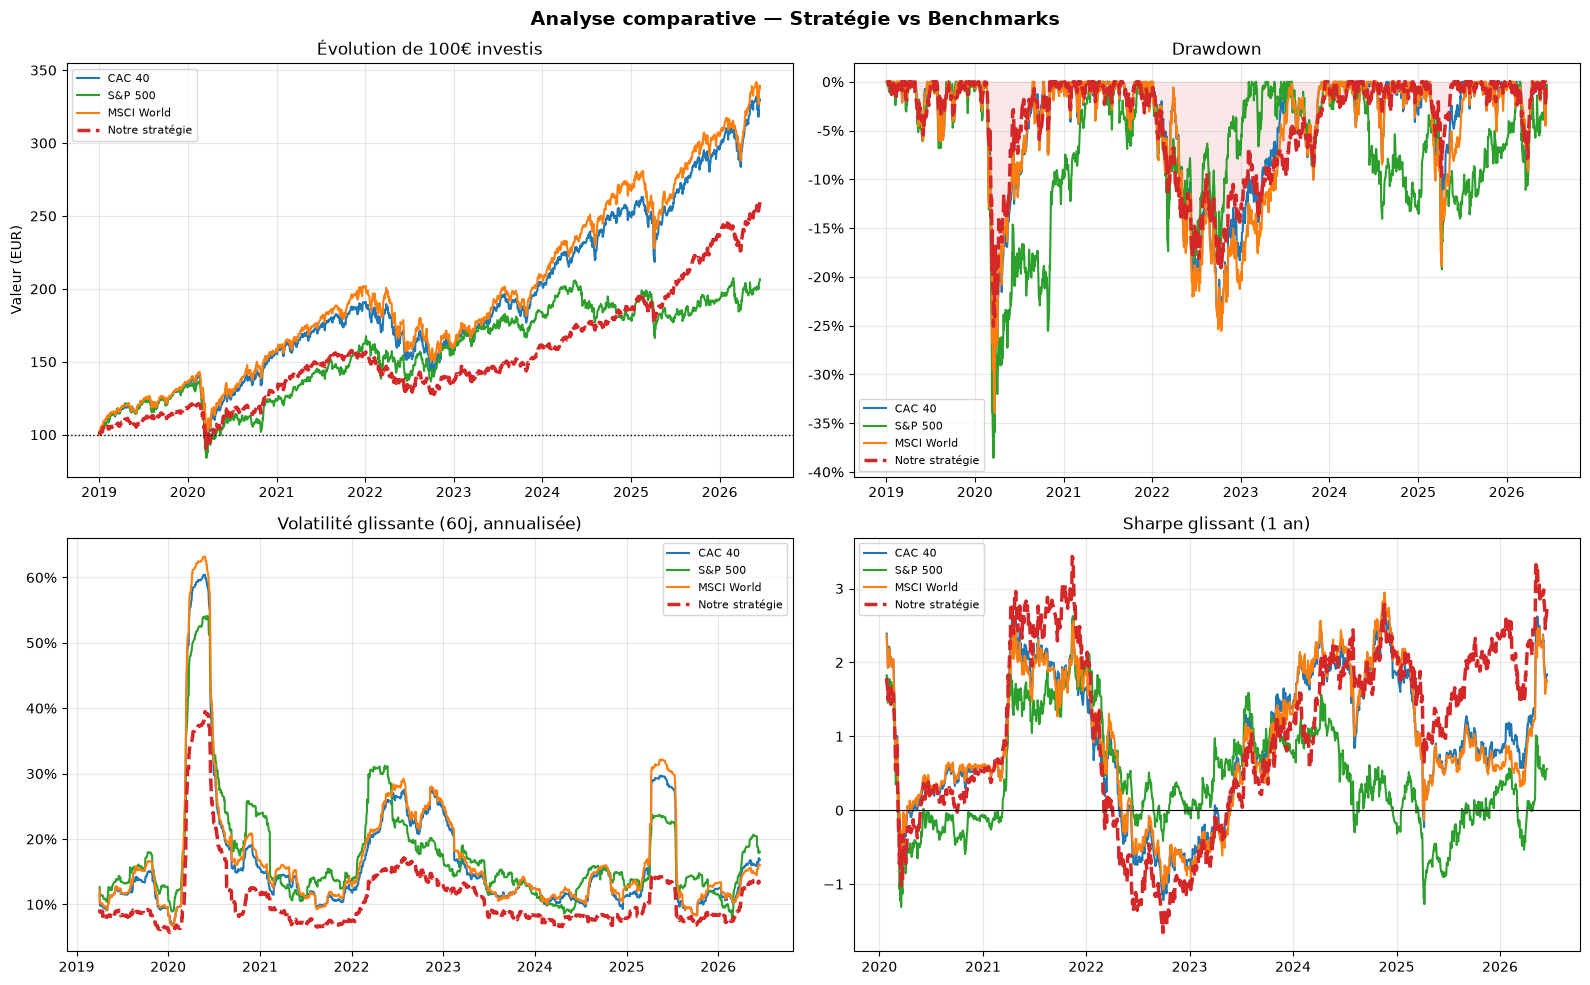

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Évolution 100€
ax = axes[0, 0]
for col in valeur_euros.columns:
    style = "--" if col == "Notre stratégie" else "-"
    lw = 2.5 if col == "Notre stratégie" else 1.5
    ax.plot(valeur_euros.index, valeur_euros[col], style, linewidth=lw,
            color=COULEURS_BENCH.get(col, "gray"), label=col)
ax.axhline(capital_initial, color="black", linewidth=1, linestyle=":")
ax.set_title("Évolution de 100€ investis")
ax.set_ylabel("Valeur (EUR)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Drawdown
ax = axes[0, 1]
drawdowns = comparaison.apply(calculer_drawdown)
for col in drawdowns.columns:
    style = "--" if col == "Notre stratégie" else "-"
    lw = 2.5 if col == "Notre stratégie" else 1.5
    ax.plot(drawdowns.index, drawdowns[col], style, linewidth=lw,
            color=COULEURS_BENCH.get(col, "gray"), label=col)
ax.fill_between(drawdowns.index, drawdowns["Notre stratégie"], 0, alpha=0.1, color="#d62728")
ax.set_title("Drawdown")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Volatilité glissante
ax = axes[1, 0]
rend_journaliers = comparaison.pct_change().dropna()
vol_glissante = rend_journaliers.rolling(60).std() * np.sqrt(252)
for col in vol_glissante.columns:
    style = "--" if col == "Notre stratégie" else "-"
    lw = 2.5 if col == "Notre stratégie" else 1.5
    ax.plot(vol_glissante.index, vol_glissante[col], style, linewidth=lw,
            color=COULEURS_BENCH.get(col, "gray"), label=col)
ax.set_title("Volatilité glissante (60j, annualisée)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Sharpe glissant
ax = axes[1, 1]
rend_ann_gl = rend_journaliers.rolling(252).mean() * 252
vol_ann_gl  = rend_journaliers.rolling(252).std() * np.sqrt(252)
sharpe_gl   = (rend_ann_gl - RISK_FREE_RATE) / vol_ann_gl
for col in sharpe_gl.columns:
    style = "--" if col == "Notre stratégie" else "-"
    lw = 2.5 if col == "Notre stratégie" else 1.5
    ax.plot(sharpe_gl.index, sharpe_gl[col], style, linewidth=lw,
            color=COULEURS_BENCH.get(col, "gray"), label=col)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Sharpe glissant (1 an)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Analyse comparative — Stratégie vs Benchmarks", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

=== Niveau de risque ===

Actif                  Vol. ann.    Max DD   VaR hist.      CVaR  Kurtosis  Score 1-7
----------------------------------------------------------------------------------------
CAC 40                   18.95%   -33.95%      -1.62%    -2.80%     16.14          6
S&P 500                  19.14%   -38.56%      -1.73%    -2.92%     12.07          6
MSCI World               19.85%   -33.92%      -1.73%    -2.97%     14.96          6
Notre stratégie          12.35%   -25.06%      -1.04%    -1.74%     14.40          5


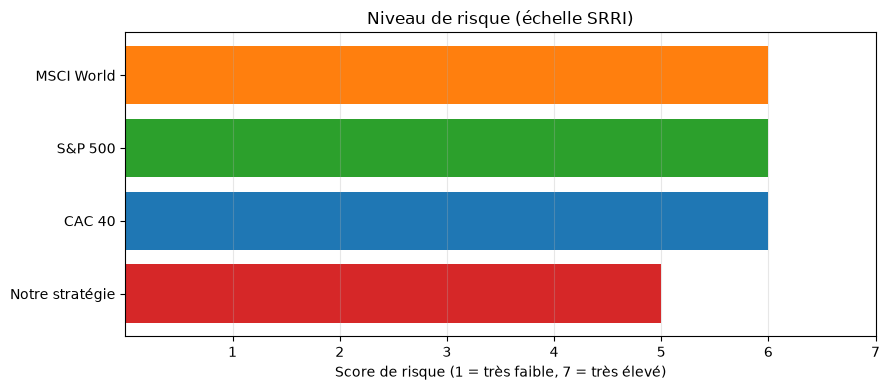

In [21]:
risques = {col: calculer_risque(comparaison[col]) for col in comparaison.columns}
df_risques = pd.DataFrame(risques).T
df_risques["Score risque (1-7)"] = df_risques["Volatilité annualisée"].apply(score_srri)

print("=== Niveau de risque ===\n")
print(f"{'Actif':<20}{'Vol. ann.':>12}{'Max DD':>10}{'VaR hist.':>12}{'CVaR':>10}{'Kurtosis':>10}{'Score 1-7':>11}")
print("-" * 88)
for col in df_risques.index:
    r = df_risques.loc[col]
    print(f"{col:<20}{r['Volatilité annualisée']:>11.2%}{r['Max Drawdown']:>10.2%}"
          f"{r['VaR 95% (historique)']:>12.2%}{r['CVaR (Expected Shortfall)']:>10.2%}"
          f"{r['Kurtosis']:>10.2f}{int(r['Score risque (1-7)']):>11}")

plt.figure(figsize=(9, 4))
scores_sorted = df_risques["Score risque (1-7)"].sort_values()
couleurs_barres = [COULEURS_BENCH.get(c, "gray") for c in scores_sorted.index]
plt.barh(scores_sorted.index, scores_sorted.values, color=couleurs_barres)
plt.xlim(0, 7)
plt.xticks(range(1, 8))
plt.xlabel("Score de risque (1 = très faible, 7 = très élevé)")
plt.title("Niveau de risque (échelle SRRI)")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Q = T/N = 347.8 | λ_max bruit = 1.110

  λ1   = 2.3501   ✅ SIGNAL
  λ2   = 1.0203   🔴 BRUIT
  λ3   = 0.8069   🔴 BRUIT
  λ4   = 0.4653   🔴 BRUIT
  λ5   = 0.3574   🔴 BRUIT

→ 1 valeur(s) propre(s) = signal réel
→ 4 valeur(s) propre(s) = bruit pur


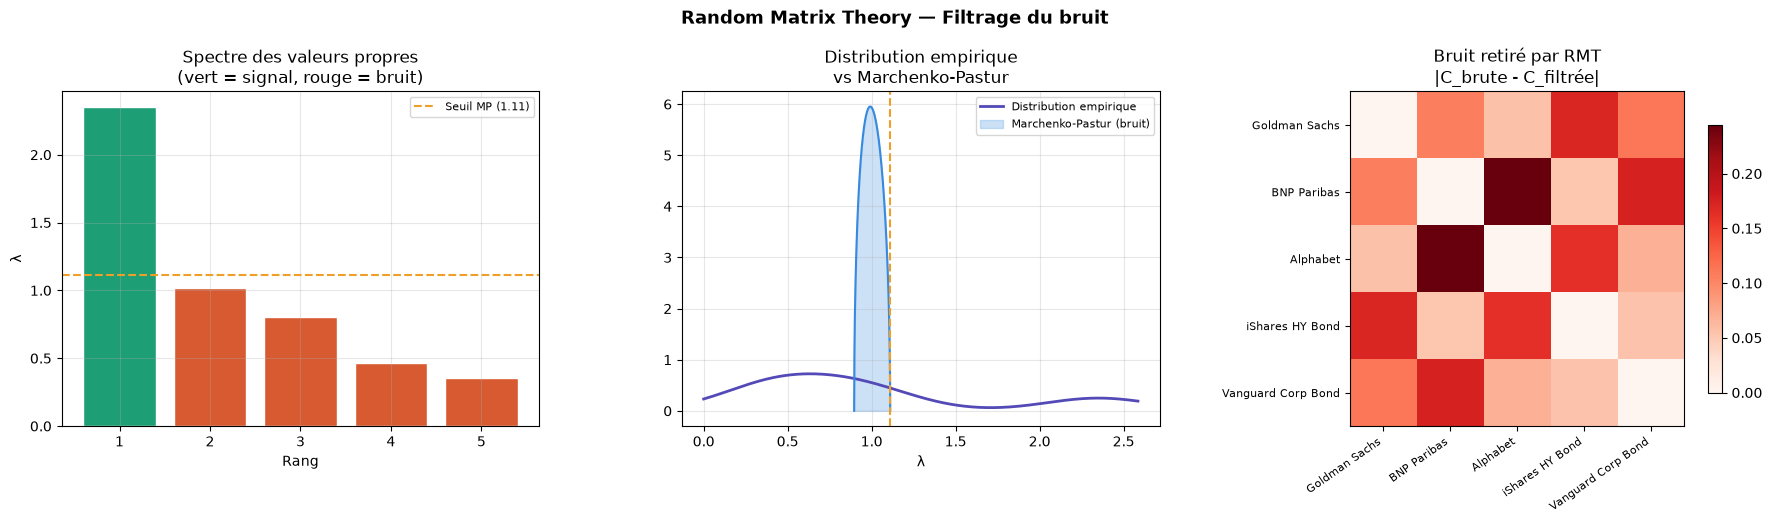

In [22]:
log_ret_rmt = np.log(prices[selected] / prices[selected].shift(1)).dropna()
T, N = log_ret_rmt.shape
C = log_ret_rmt.corr().values
eigenvalues = np.sort(np.linalg.eigvalsh(C))[::-1]

Q = T / N
sigma2 = 1.0
lambda_max = sigma2 * (1 + 1/Q + 2/np.sqrt(Q))
lambda_min = sigma2 * (1 + 1/Q - 2/np.sqrt(Q))

print(f"Q = T/N = {Q:.1f} | λ_max bruit = {lambda_max:.3f}\n")
for i, val in enumerate(eigenvalues):
    statut = "✅ SIGNAL" if val > lambda_max else "🔴 BRUIT"
    print(f"  λ{i+1:<3} = {val:.4f}   {statut}")

n_signal = (eigenvalues > lambda_max).sum()
print(f"\n→ {n_signal} valeur(s) propre(s) = signal réel")
print(f"→ {N - n_signal} valeur(s) propre(s) = bruit pur")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Spectre des valeurs propres
ax = axes[0]
colors = ["#1D9E75" if v > lambda_max else "#D85A30" for v in eigenvalues]
ax.bar(range(1, N+1), eigenvalues, color=colors, edgecolor="white")
ax.axhline(lambda_max, color="#EF9F27", linestyle="--", lw=1.5, label=f"Seuil MP ({lambda_max:.2f})")
ax.set_title("Spectre des valeurs propres\n(vert = signal, rouge = bruit)")
ax.set_xlabel("Rang")
ax.set_ylabel("λ")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Distribution empirique vs Marchenko-Pastur
ax = axes[1]
kde = gaussian_kde(eigenvalues, bw_method=0.4)
x_range = np.linspace(0, eigenvalues.max() * 1.1, 300)
ax.plot(x_range, kde(x_range), color="#534AB7", lw=2, label="Distribution empirique")
x_mp = np.linspace(max(lambda_min, 0.01), lambda_max, 300)
rho_mp = (Q / (2 * np.pi * sigma2)) * np.sqrt(
    np.maximum((lambda_max - x_mp) * (x_mp - lambda_min), 0)) / x_mp
ax.fill_between(x_mp, rho_mp, alpha=0.25, color="#378ADD", label="Marchenko-Pastur (bruit)")
ax.plot(x_mp, rho_mp, color="#378ADD", lw=1.5)
ax.axvline(lambda_max, color="#EF9F27", linestyle="--", lw=1.5)
ax.set_title("Distribution empirique\nvs Marchenko-Pastur")
ax.set_xlabel("λ")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Matrice filtrée vs brute
ax = axes[2]
eigenvalues_full, eigenvectors = np.linalg.eigh(C)
idx = np.argsort(eigenvalues_full)[::-1]
eigenvalues_full = eigenvalues_full[idx]
eigenvectors = eigenvectors[:, idx]
eigenvalues_filtered = eigenvalues_full.copy()
eigenvalues_filtered[eigenvalues_filtered <= lambda_max] = 0
C_filtered = eigenvectors @ np.diag(eigenvalues_filtered) @ eigenvectors.T
np.fill_diagonal(C_filtered, 1.0)
diff_matrix = np.abs(C - C_filtered)
im = ax.imshow(diff_matrix, cmap="Reds", vmin=0, vmax=diff_matrix.max())
plt.colorbar(im, ax=ax, shrink=0.8)
labels = [ASSETS.get(t, t) for t in selected]
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Bruit retiré par RMT\n|C_brute - C_filtrée|")

plt.suptitle("Random Matrix Theory — Filtrage du bruit", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()